In [6]:
# Overfitting, Dropout, Batch Normalisation & Regularisation

Code — Overfitting Lab

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import copy

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Use a SMALL subset of MNIST to make overfitting obvious
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
full_train = datasets.MNIST('./data', train=True,  download=True, transform=transform)
full_test  = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Intentionally small: 1000 train, 2000 test → easy to overfit
small_train = Subset(full_train, range(1000))
small_test  = Subset(full_test,  range(2000))

train_loader = DataLoader(small_train, batch_size=32, shuffle=True)
test_loader  = DataLoader(small_test,  batch_size=64, shuffle=False)

print(f"Train: {len(small_train)} | Test: {len(small_test)}")
print("Small dataset → overfitting will be obvious within 20 epochs")

Device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 61.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.59MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.74MB/s]


Train: 1000 | Test: 2000
Small dataset → overfitting will be obvious within 20 epochs


Section A — Deliberately cause overfitting


In [8]:
print("=" * 55)
print("SECTION A: Deliberate overfitting — the control")
print("=" * 55)

class OverfitNet(nn.Module):
    """Intentionally large network for a tiny dataset — will overfit badly."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, 512),  nn.ReLU(),
            nn.Linear(512,  10)
        )
    def forward(self, x): return self.net(x)

def run_training(model, train_loader, test_loader,
                 epochs=40, lr=0.001, label=""):
    model = model.to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    crit  = nn.CrossEntropyLoss()
    hist  = {"train_loss":[], "test_loss":[], "train_acc":[], "test_acc":[]}

    for epoch in range(epochs):
        # Train
        model.train()
        tr_loss, tr_correct, tr_total = 0, 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            out  = model(X)
            loss = crit(out, y)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss    += loss.item()
            tr_correct += (out.argmax(1)==y).sum().item()
            tr_total   += y.size(0)

        # Eval
        model.eval()
        te_loss, te_correct, te_total = 0, 0, 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                out  = model(X)
                loss = crit(out, y)
                te_loss    += loss.item()
                te_correct += (out.argmax(1)==y).sum().item()
                te_total   += y.size(0)

        hist["train_loss"].append(tr_loss/len(train_loader))
        hist["test_loss"].append(te_loss/len(test_loader))
        hist["train_acc"].append(tr_correct/tr_total)
        hist["test_acc"].append(te_correct/te_total)

        if (epoch+1) % 10 == 0:
            print(f"  [{label}] Ep {epoch+1:3d} | "
                  f"train {hist['train_acc'][-1]*100:.1f}% loss {hist['train_loss'][-1]:.3f} | "
                  f"test  {hist['test_acc'][-1]*100:.1f}% loss {hist['test_loss'][-1]:.3f}")
    return hist

print("Training overfit network...")
hist_overfit = run_training(OverfitNet(), train_loader, test_loader,
                             epochs=40, label="Overfit")

# The gap between train and test is the overfitting signal
final_gap = (hist_overfit["train_acc"][-1] - hist_overfit["test_acc"][-1]) * 100
print(f"\nFinal accuracy gap (train - test): {final_gap:.1f}%")
print("Large gap = overfitting confirmed.")

SECTION A: Deliberate overfitting — the control
Training overfit network...
  [Overfit] Ep  10 | train 98.7% loss 0.034 | test  85.0% loss 0.667
  [Overfit] Ep  20 | train 97.9% loss 0.065 | test  82.3% loss 1.022
  [Overfit] Ep  30 | train 99.7% loss 0.013 | test  85.9% loss 0.791
  [Overfit] Ep  40 | train 100.0% loss 0.002 | test  86.6% loss 0.886

Final accuracy gap (train - test): 13.4%
Large gap = overfitting confirmed.


Section B — Fix with Dropout



SECTION B: Dropout — the simplest fix

Training with dropout p=0.0...
  [dropout p=0.0] Ep  10 | train 95.8% loss 0.132 | test  85.8% loss 0.632
  [dropout p=0.0] Ep  20 | train 100.0% loss 0.000 | test  85.9% loss 0.955
  [dropout p=0.0] Ep  30 | train 100.0% loss 0.000 | test  86.2% loss 1.047
  [dropout p=0.0] Ep  40 | train 100.0% loss 0.000 | test  86.2% loss 1.096

Training with dropout p=0.2...
  [dropout p=0.2] Ep  10 | train 96.9% loss 0.126 | test  84.0% loss 0.771
  [dropout p=0.2] Ep  20 | train 98.8% loss 0.044 | test  84.9% loss 0.924
  [dropout p=0.2] Ep  30 | train 99.3% loss 0.028 | test  83.2% loss 1.131
  [dropout p=0.2] Ep  40 | train 99.9% loss 0.003 | test  87.3% loss 0.847

Training with dropout p=0.5...
  [dropout p=0.5] Ep  10 | train 93.7% loss 0.165 | test  83.5% loss 0.617
  [dropout p=0.5] Ep  20 | train 97.9% loss 0.077 | test  85.8% loss 0.722
  [dropout p=0.5] Ep  30 | train 98.3% loss 0.059 | test  86.7% loss 0.700
  [dropout p=0.5] Ep  40 | train 97.6

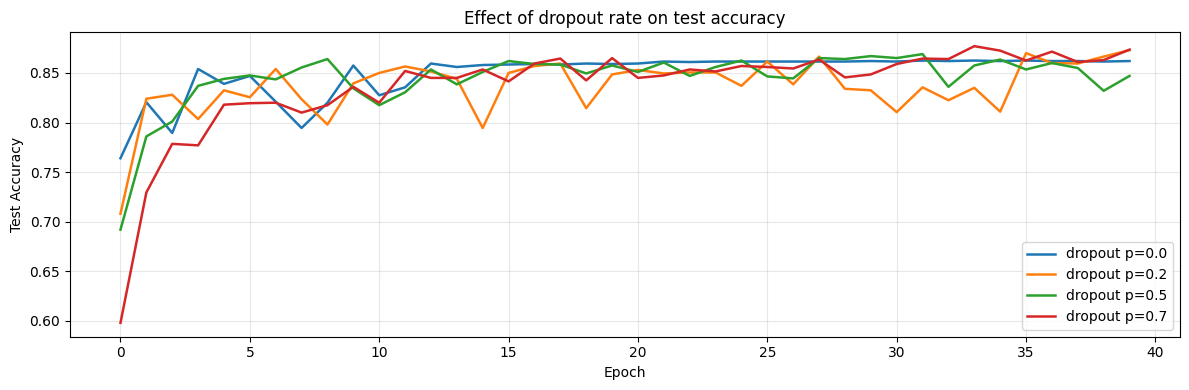


── Dropout: train mode vs eval mode ──
Train mode output 1: [-0.088 -0.075  0.002]
Train mode output 2: [0.072 0.051 0.05 ]
Same? False

Eval mode output 1: [-0.038 -0.054 -0.023]
Eval mode output 2: [-0.038 -0.054 -0.023]
Same? True

Forget model.eval() → random predictions at inference. Classic bug.


In [9]:
print("\n" + "=" * 55)
print("SECTION B: Dropout — the simplest fix")
print("=" * 55)

class DropoutNet(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 1024), nn.ReLU(), nn.Dropout(p),
            nn.Linear(1024, 1024), nn.ReLU(), nn.Dropout(p),
            nn.Linear(1024, 512),  nn.ReLU(), nn.Dropout(p/2),
            nn.Linear(512,  10)
        )
    def forward(self, x): return self.net(x)

# Try different dropout rates
dropout_results = {}
for p in [0.0, 0.2, 0.5, 0.7]:
    label = f"dropout p={p}"
    print(f"\nTraining with {label}...")
    hist = run_training(DropoutNet(p), train_loader, test_loader,
                        epochs=40, label=label)
    dropout_results[label] = hist

# Plot: compare test accuracy for different dropout values
plt.figure(figsize=(12, 4))
for label, hist in dropout_results.items():
    plt.plot(hist["test_acc"], label=label, linewidth=1.8)
plt.title("Effect of dropout rate on test accuracy")
plt.xlabel("Epoch"); plt.ylabel("Test Accuracy")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# CRITICAL: demonstrate train vs eval mode
print("\n── Dropout: train mode vs eval mode ──")
model_dp = DropoutNet(p=0.5).to(device)
X_sample = next(iter(test_loader))[0][:1].to(device)

# In train mode — output is different each call (stochastic)
model_dp.train()
out1 = model_dp(X_sample).detach().cpu()
out2 = model_dp(X_sample).detach().cpu()
print(f"Train mode output 1: {out1[0,:3].numpy().round(3)}")
print(f"Train mode output 2: {out2[0,:3].numpy().round(3)}")
print(f"Same? {torch.allclose(out1, out2)}")

# In eval mode — output is deterministic
model_dp.eval()
with torch.no_grad():
    out3 = model_dp(X_sample).cpu()
    out4 = model_dp(X_sample).cpu()
print(f"\nEval mode output 1: {out3[0,:3].numpy().round(3)}")
print(f"Eval mode output 2: {out4[0,:3].numpy().round(3)}")
print(f"Same? {torch.allclose(out3, out4)}")
print("\nForget model.eval() → random predictions at inference. Classic bug.")

Section C — Fix with L2 regularisation


In [10]:
print("\n" + "=" * 55)
print("SECTION C: L2 regularisation (weight decay)")
print("=" * 55)

# L2 adds λ·||W||² to the loss
# In PyTorch this is handled by the optimizer via weight_decay
# Equivalent to: loss_total = loss_ce + lambda * sum(w**2)

l2_results = {}
for wd in [0, 1e-4, 1e-3, 1e-2]:
    model = OverfitNet().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)
    crit  = nn.CrossEntropyLoss()
    hist  = {"train_loss":[], "test_loss":[], "train_acc":[], "test_acc":[]}

    for epoch in range(40):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            out = model(X); loss = crit(out, y)
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        tr_loss, te_loss, tr_acc, te_acc = 0,0,0,0
        with torch.no_grad():
            for X, y in train_loader:
                X,y = X.to(device), y.to(device)
                out = model(X); tr_loss += crit(out,y).item()
                tr_acc += (out.argmax(1)==y).float().mean().item()
            for X, y in test_loader:
                X,y = X.to(device), y.to(device)
                out = model(X); te_loss += crit(out,y).item()
                te_acc += (out.argmax(1)==y).float().mean().item()
        hist["train_loss"].append(tr_loss/len(train_loader))
        hist["test_loss"].append(te_loss/len(test_loader))
        hist["train_acc"].append(tr_acc/len(train_loader))
        hist["test_acc"].append(te_acc/len(test_loader))

    l2_results[f"wd={wd}"] = hist
    print(f"weight_decay={wd:6.0e} | "
          f"train {hist['train_acc'][-1]*100:.1f}% | "
          f"test  {hist['test_acc'][-1]*100:.1f}% | "
          f"gap {(hist['train_acc'][-1]-hist['test_acc'][-1])*100:.1f}%")

# Visualise weight magnitude with vs without L2
print("\n── Effect on weight magnitudes ──")
for wd in [0, 1e-3]:
    model = OverfitNet().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)
    crit  = nn.CrossEntropyLoss()
    for epoch in range(20):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            out = model(X); loss = crit(out, y)
            opt.zero_grad(); loss.backward(); opt.step()
    w_norm = sum(p.abs().mean().item()
                 for p in model.parameters()) / len(list(model.parameters()))
    print(f"  weight_decay={wd} → avg |weight|: {w_norm:.4f}")
print("L2 actively pushes weights toward zero → smaller, simpler model")


SECTION C: L2 regularisation (weight decay)
weight_decay= 0e+00 | train 100.0% | test  87.1% | gap 12.9%
weight_decay= 1e-04 | train 100.0% | test  87.0% | gap 13.0%
weight_decay= 1e-03 | train 100.0% | test  87.1% | gap 12.9%
weight_decay= 1e-02 | train 99.9% | test  84.4% | gap 15.5%

── Effect on weight magnitudes ──
  weight_decay=0 → avg |weight|: 0.0193
  weight_decay=0.001 → avg |weight|: 0.0117
L2 actively pushes weights toward zero → smaller, simpler model


Section D — Batch Normalisation deep dive



SECTION D: Batch Normalisation — see what it does
Training WITHOUT BatchNorm...
  [No BN] Ep  10 | train 99.2% loss 0.024 | test  97.8% loss 0.094

Training WITH BatchNorm...
  [With BN] Ep  10 | train 99.3% loss 0.020 | test  98.1% loss 0.066


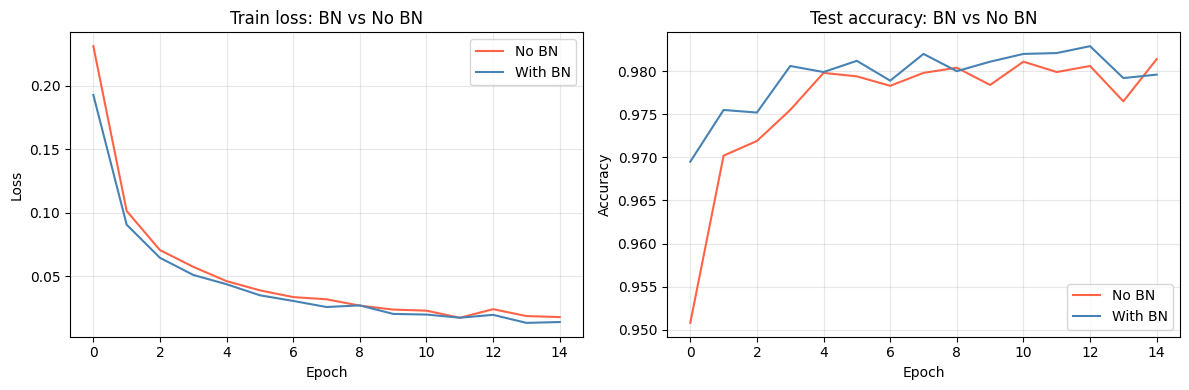


── Activation distributions: with vs without BN ──


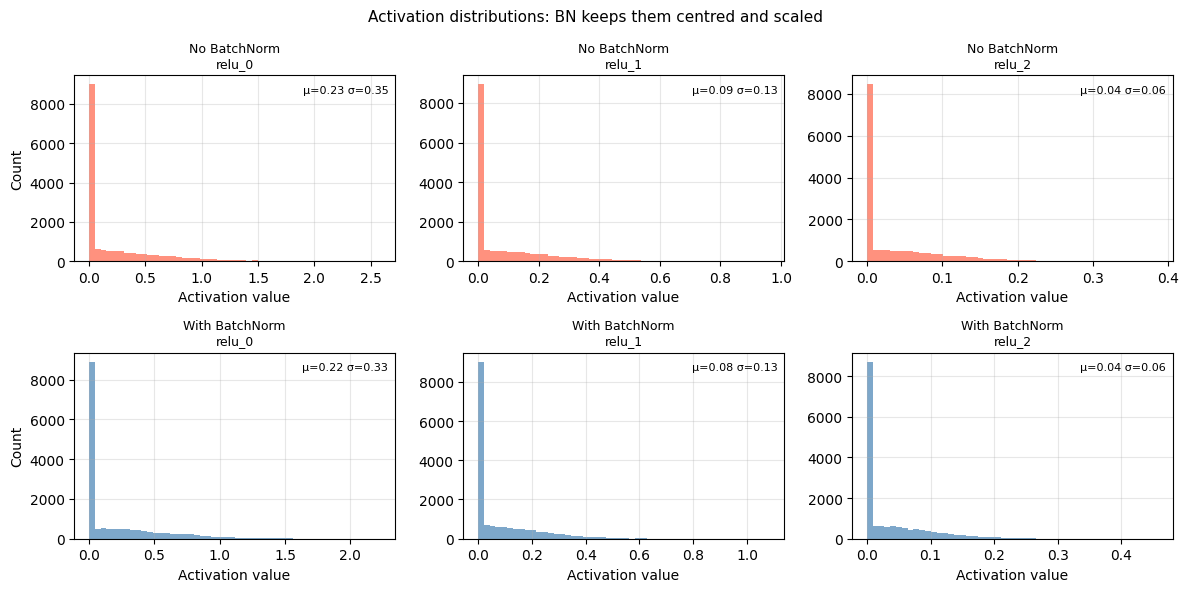

In [11]:
print("\n" + "=" * 55)
print("SECTION D: Batch Normalisation — see what it does")
print("=" * 55)

class NetNoBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

class NetWithBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

# Use FULL dataset for this experiment
full_loader_tr = DataLoader(full_train, batch_size=64, shuffle=True)
full_loader_te = DataLoader(full_test,  batch_size=64, shuffle=False)

print("Training WITHOUT BatchNorm...")
hist_nobn  = run_training(NetNoBN(),   full_loader_tr, full_loader_te,
                           epochs=15, label="No BN")

print("\nTraining WITH BatchNorm...")
hist_withbn = run_training(NetWithBN(), full_loader_tr, full_loader_te,
                            epochs=15, label="With BN")

# Compare convergence speed
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hist, label, color in [(hist_nobn, "No BN", "tomato"),
                             (hist_withbn, "With BN", "steelblue")]:
    axes[0].plot(hist["train_loss"], label=label, color=color)
    axes[1].plot(hist["test_acc"],   label=label, color=color)
axes[0].set_title("Train loss: BN vs No BN")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title("Test accuracy: BN vs No BN")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Visualise activation distributions — this is the point of BN
print("\n── Activation distributions: with vs without BN ──")
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for row, (model, title) in enumerate([(NetNoBN(), "No BatchNorm"),
                                        (NetWithBN(), "With BatchNorm")]):
    model = model.to(device)
    X_sample, _ = next(iter(full_loader_tr))
    X_sample = X_sample.to(device)

    # Hook to capture activations
    activations = {}
    def make_hook(name):
        def hook(module, inp, out):
            activations[name] = out.detach().cpu()
        return hook

    # Register hooks on ReLU layers
    hooks = []
    relu_count = 0
    for m in model.modules():
        if isinstance(m, nn.ReLU):
            hooks.append(m.register_forward_hook(make_hook(f"relu_{relu_count}")))
            relu_count += 1

    model.eval()
    with torch.no_grad(): model(X_sample)
    for h in hooks: h.remove()

    for col, (act_name, ax) in enumerate(zip(list(activations.keys())[:3], axes[row])):
        vals = activations[act_name].numpy().flatten()
        ax.hist(vals, bins=50, color='steelblue' if row==1 else 'tomato', alpha=0.7)
        ax.set_title(f"{title}\n{act_name}", fontsize=9)
        ax.set_xlabel("Activation value")
        if col == 0: ax.set_ylabel("Count")
        stats = f"μ={vals.mean():.2f} σ={vals.std():.2f}"
        ax.text(0.98, 0.95, stats, transform=ax.transAxes,
                ha='right', va='top', fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Activation distributions: BN keeps them centred and scaled", fontsize=11)
plt.tight_layout(); plt.show()

Section E — Early stopping



SECTION E: Early stopping — stop before you overfit
Training with early stopping (patience=5)...

Epoch   1 | train 83.9% | test 72.5%
    ✓ New best: 0.8726
Epoch   2 | train 92.3% | test 79.8%
    ✓ New best: 0.5831
Epoch   3 | train 94.4% | test 81.7%
    No improvement (1/5)
Epoch   4 | train 96.6% | test 84.3%
    ✓ New best: 0.5434
Epoch   5 | train 98.0% | test 83.3%
    No improvement (1/5)
Epoch   6 | train 98.6% | test 86.4%
    ✓ New best: 0.5090
Epoch   7 | train 94.4% | test 77.7%
    No improvement (1/5)
Epoch   8 | train 97.3% | test 83.5%
    No improvement (2/5)
Epoch   9 | train 98.7% | test 85.4%
    No improvement (3/5)
Epoch  10 | train 98.7% | test 86.4%
    No improvement (4/5)
Epoch  11 | train 98.3% | test 81.3%
    No improvement (5/5)

Early stopping at epoch 11!
Restored best weights (from epoch 6)


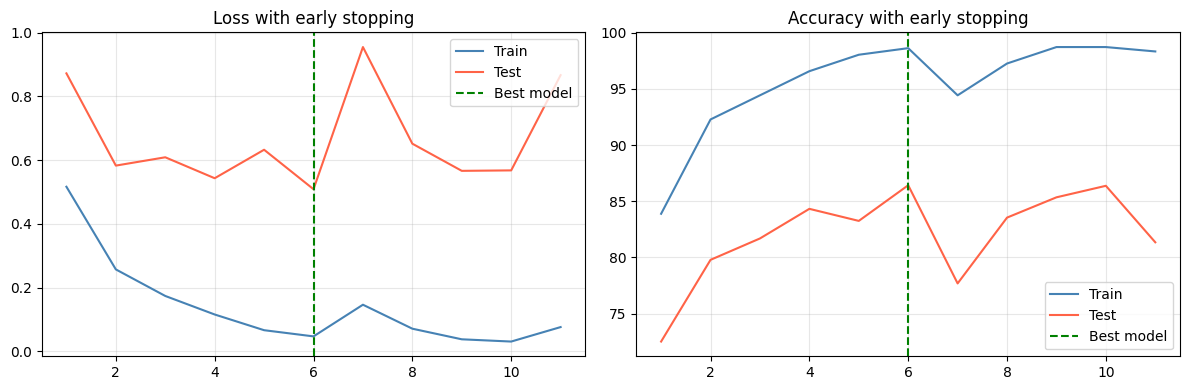

In [12]:
print("\n" + "=" * 55)
print("SECTION E: Early stopping — stop before you overfit")
print("=" * 55)

class EarlyStopping:
    """
    Stops training when val_loss hasn't improved for `patience` epochs.
    Saves the best model weights automatically.
    """
    def __init__(self, patience=5, min_delta=1e-4, verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_state = None
        self.stopped_epoch = 0

    def __call__(self, val_loss, model, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            # Deep copy weights at best point
            self.best_state = copy.deepcopy(model.state_dict())
            if self.verbose:
                print(f"    ✓ New best: {val_loss:.4f}")
        else:
            self.counter += 1
            if self.verbose:
                print(f"    No improvement ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.stopped_epoch = epoch
                return True   # signal to stop
        return False

    def restore_best(self, model):
        model.load_state_dict(self.best_state)
        print(f"Restored best weights (from epoch {self.stopped_epoch - self.patience})")

# Train with early stopping
model_es  = DropoutNet(p=0.4).to(device)
opt_es    = torch.optim.Adam(model_es.parameters(), lr=0.001, weight_decay=1e-4)
crit      = nn.CrossEntropyLoss()
es        = EarlyStopping(patience=5, verbose=True)
hist_es   = {"train_loss":[], "test_loss":[], "train_acc":[], "test_acc":[]}

print("Training with early stopping (patience=5)...\n")
for epoch in range(100):      # set high — early stopping will interrupt
    model_es.train()
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        out = model_es(X); loss = crit(out, y)
        opt_es.zero_grad(); loss.backward(); opt_es.step()

    model_es.eval()
    tr_loss, tr_acc = 0, 0
    te_loss, te_acc = 0, 0
    with torch.no_grad():
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            out = model_es(X)
            tr_loss += crit(out,y).item()
            tr_acc  += (out.argmax(1)==y).float().mean().item()
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            out = model_es(X)
            te_loss += crit(out,y).item()
            te_acc  += (out.argmax(1)==y).float().mean().item()

    trl = tr_loss/len(train_loader); tel = te_loss/len(test_loader)
    tra = tr_acc/len(train_loader);  tea = te_acc/len(test_loader)
    hist_es["train_loss"].append(trl); hist_es["test_loss"].append(tel)
    hist_es["train_acc"].append(tra);  hist_es["test_acc"].append(tea)

    print(f"Epoch {epoch+1:3d} | train {tra*100:.1f}% | test {tea*100:.1f}%")
    if es(tel, model_es, epoch+1):
        print(f"\nEarly stopping at epoch {epoch+1}!")
        break

es.restore_best(model_es)

# Plot with vertical line where we stopped
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(hist_es["train_loss"])+1)
ax1.plot(ep, hist_es["train_loss"], label="Train", color="steelblue")
ax1.plot(ep, hist_es["test_loss"],  label="Test",  color="tomato")
ax1.axvline(es.stopped_epoch - es.patience, color='green',
            linestyle='--', label='Best model')
ax1.set_title("Loss with early stopping"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, [a*100 for a in hist_es["train_acc"]], label="Train", color="steelblue")
ax2.plot(ep, [a*100 for a in hist_es["test_acc"]],  label="Test",  color="tomato")
ax2.axvline(es.stopped_epoch - es.patience, color='green',
            linestyle='--', label='Best model')
ax2.set_title("Accuracy with early stopping"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Section F — Everything together: the regularised model



SECTION F: Full regularised pipeline — all techniques combined
Training UNREGULARISED model...
  [Unregularised] Ep  10 | train 86.0% loss 0.390 | test  83.5% loss 0.472
  [Unregularised] Ep  20 | train 91.4% loss 0.252 | test  89.3% loss 0.337
  [Unregularised] Ep  30 | train 91.2% loss 0.260 | test  87.8% loss 0.411
  [Unregularised] Ep  40 | train 95.4% loss 0.175 | test  93.5% loss 0.213

Training REGULARISED model...
  Epoch  10 | train 87.0% | test  86.5%
  Epoch  20 | train 90.9% | test  90.5%
  Epoch  30 | train 92.0% | test  90.5%
Restored best weights (from epoch 23)

── Final comparison ──
Model                | Train Acc | Test Acc |    Gap
----------------------------------------------------
Unregularised        |     95.4% |    93.5% |   1.9%
Regularised          |     92.0% |    90.5% |   1.5%


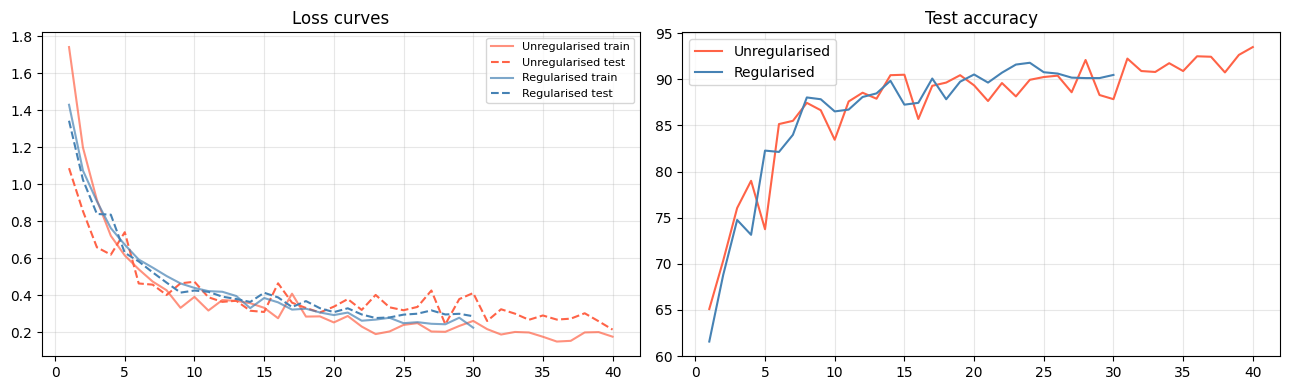

In [13]:
print("\n" + "=" * 55)
print("SECTION F: Full regularised pipeline — all techniques combined")
print("=" * 55)

# Augment the small training set
aug_transform = transforms.Compose([
    transforms.RandomRotation(12),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
aug_train  = datasets.MNIST('./data', train=True,  transform=aug_transform)
aug_small  = Subset(aug_train, range(1000))
aug_loader = DataLoader(aug_small, batch_size=32, shuffle=True)

class RegularisedNet(nn.Module):
    """Best practices: BN + Dropout + good architecture."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

# Compare: unregularised vs fully regularised
print("Training UNREGULARISED model...")
hist_unreg = run_training(OverfitNet(), aug_loader, test_loader,
                           epochs=40, lr=0.001, label="Unregularised")

print("\nTraining REGULARISED model...")
model_reg = RegularisedNet().to(device)
opt_reg   = torch.optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-4)
crit      = nn.CrossEntropyLoss()
es_reg    = EarlyStopping(patience=7, verbose=False)
hist_reg  = {"train_loss":[], "test_loss":[], "train_acc":[], "test_acc":[]}

for epoch in range(60):
    model_reg.train()
    for X, y in aug_loader:
        X, y = X.to(device), y.to(device)
        out = model_reg(X); loss = crit(out, y)
        opt_reg.zero_grad(); loss.backward(); opt_reg.step()

    model_reg.eval()
    tr_l, tr_a, te_l, te_a = 0,0,0,0
    with torch.no_grad():
        for X,y in aug_loader:
            X,y=X.to(device),y.to(device); out=model_reg(X)
            tr_l+=crit(out,y).item(); tr_a+=(out.argmax(1)==y).float().mean().item()
        for X,y in test_loader:
            X,y=X.to(device),y.to(device); out=model_reg(X)
            te_l+=crit(out,y).item(); te_a+=(out.argmax(1)==y).float().mean().item()

    hist_reg["train_loss"].append(tr_l/len(aug_loader))
    hist_reg["test_loss"].append(te_l/len(test_loader))
    hist_reg["train_acc"].append(tr_a/len(aug_loader))
    hist_reg["test_acc"].append(te_a/len(test_loader))

    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d} | "
              f"train {hist_reg['train_acc'][-1]*100:.1f}% | "
              f"test  {hist_reg['test_acc'][-1]*100:.1f}%")

    if es_reg(hist_reg["test_loss"][-1], model_reg, epoch+1): break

es_reg.restore_best(model_reg)

# Final comparison
print("\n── Final comparison ──")
print(f"{'Model':20s} | {'Train Acc':>9} | {'Test Acc':>8} | {'Gap':>6}")
print("-" * 52)
for label, hist in [("Unregularised", hist_unreg), ("Regularised", hist_reg)]:
    tr = hist['train_acc'][-1]*100; te = hist['test_acc'][-1]*100
    print(f"{label:20s} | {tr:>8.1f}% | {te:>7.1f}% | {tr-te:>5.1f}%")

# Side-by-side loss curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for hist, label, c in [(hist_unreg, "Unregularised", "tomato"),
                         (hist_reg,   "Regularised",   "steelblue")]:
    ep = range(1, len(hist["train_loss"])+1)
    axes[0].plot(ep, hist["train_loss"], label=f"{label} train", linestyle='-',  color=c, alpha=0.7)
    axes[0].plot(ep, hist["test_loss"],  label=f"{label} test",  linestyle='--', color=c)
    axes[1].plot(ep, [a*100 for a in hist["test_acc"]], label=label, color=c)

axes[0].set_title("Loss curves"); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_title("Test accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()